# **Análisis de datos del proyecto**

En este cuaderno se encuentra el código necesario para analizar tanto los datos de recompensa por episodio, obtenidos con los logs, como las métricas de desempeño de los multiplicadores con un error menor o igual al 10%, obtenidas con OpenLane. La modularización del código responde a los requisitos comunes para ambos análisis, como las librerías utilizadas, y el preprocesamiento de los datos por aparte dependiendo de cuáles datos se desean visualizar.

## Código común: importación de librerías e inicialización de funciones

In [13]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
try:
    drive.mount('/content/drive')
except Exception:
    pass

def convertir_a_minutos(tiempo_str: str) -> float:
    """
    Convierte '0h1m21s0ms' a minutos decimales. Acepta '1m', '21s', '350ms', '2h5s', etc.
    """
    if not isinstance(tiempo_str, str):
        return 0.0
    m = re.fullmatch(r'(?:(\d+)h)?(?:(\d+)m)?(?:(\d+)s)?(?:(\d+)ms)?', tiempo_str.strip())
    if not m:
        return 0.0
    h, mi, s, ms = (int(x) if x else 0 for x in m.groups())
    return h * 60 + mi + s / 60 + ms / 60000

def _maybe_mount_drive():
    try:
        from google.colab import drive as _drive  # type: ignore
        if not os.path.ismount("/content/drive"):
            _drive.mount("/content/drive", force_remount=False)
    except Exception:
        # Fuera de Colab, sigue sin montar
        pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Análisis de datos: métricas de los logs


# Análisis de datos: métricas de OpenLane

Para encontrar una correlación entre las características del algoritmo de multiplicación encontrado por la IA (N° de bits y error total del multiplicador) y las métricas de desempeño más relevantes (frecuencia de operación, potencia consumida, área de silicio, N° de compuertas, etc) se utiliza el siguiente código.

## Clase OpenLaneAnalyzer

In [14]:
class OpenLaneAnalyzer:
    """
    Carga/combina CSVs, extrae 'error' y 'bits' y prepara:
      - raw_data: dataframes sin agrupar
      - grouped_data: dataframes agrupados por bits y error
    """

    def __init__(self, folders: list[str], combined_name: str = "combined_metrics.csv"):
        self.folders = folders
        self.combined_name = combined_name
        self.df = self._load_or_combine()
        self._extract_error()
        self._extract_bits()  # <<--- NUEVO
        self.raw_data: dict[str, pd.DataFrame] = {}
        self.grouped_data: dict[str, pd.DataFrame] = {}
        self._prepare_all()

    def _load_or_combine(self) -> pd.DataFrame:
        _maybe_mount_drive()

        all_csvs = []
        for folder in self.folders:
            all_csvs.extend(glob.glob(os.path.join(folder, "*.csv")))

        if not all_csvs:
            raise FileNotFoundError(f"No se encontraron CSVs en: {self.folders}")

        combined_candidates = [p for p in all_csvs if os.path.basename(p) == self.combined_name]
        if combined_candidates:
            path = max(combined_candidates, key=lambda p: os.path.getsize(p))
            return pd.read_csv(path)

        dfs = []
        for f in sorted(all_csvs):
            df = pd.read_csv(f)

            if "Metric" in df.columns and "Value" in df.columns:
                df_t = df.set_index("Metric").T
                design_name = os.path.basename(f).replace("_metrics.csv", "")
                df_t.index = [design_name]
                df_t["design_name"] = design_name
                df_t = df_t.apply(pd.to_numeric, errors="ignore")
                dfs.append(df_t)
            else:
                df["design_name"] = os.path.basename(f).replace("_metrics.csv", "")
                dfs.append(df)

        combined = pd.concat(dfs, ignore_index=True)

        out = os.path.join(self.folders[0], self.combined_name)
        os.makedirs(self.folders[0], exist_ok=True)
        combined.to_csv(out, index=False)
        print(f"Guardado combinado en {out}: {len(combined)} filas.")
        return combined

    def _extract_error(self):
        """
        Extrae el número de error desde design_name.
        Toma la última ocurrencia de 'eX' o 'errX' en el nombre.
        Acepta decimales con coma o punto.
        """
        pattern = r"e(?:rr)?_?(\d+(?:[.,]\d+)?)"

        names = self.df["design_name"].astype(str).str.strip()

        def extract_last_error(name: str):
            matches = re.findall(pattern, name, flags=re.IGNORECASE)
            if not matches:
                return None
            last = matches[-1].replace(",", ".")
            try:
                return float(last)
            except Exception:
                return None

        extracted = names.apply(extract_last_error)

        if extracted.isna().any():
            faltantes = names[extracted.isna()].unique().tolist()
            print(f"[WARN] No se pudo extraer el error de {len(faltantes)} design_name(s). Ejemplos: {faltantes[:10]}")

        self.df["error"] = extracted

    def _extract_bits(self):
        """
        Extrae el número de bits desde el prefijo del nombre del diseño.
        Busca 'mult2', 'mult4', 'mult8' (case-insensitive).
        """
        def get_bits(name: str):
            name = name.lower()
            if name.startswith("mult2"):
                return 2
            elif name.startswith("mult4"):
                return 4
            elif name.startswith("mult8"):
                return 8
            return None

        self.df["bits"] = self.df["design_name"].astype(str).apply(get_bits)

    def _prepare_all(self):
        self._prepare_area()
        self._prepare_power()
        self._prepare_path()
        self._prepare_gates()
        #self._prepare_time()

    def _register_grouped(self, key: str, df: pd.DataFrame, agg_map: dict | None = None):
        df_num = df.apply(pd.to_numeric, errors="ignore")

        numeric_cols = df_num.select_dtypes(include=[np.number]).columns.tolist()
        for col in ["error", "bits"]:
            if col in numeric_cols:
                numeric_cols.remove(col)

        if not numeric_cols:
            print(f"[WARN] No columnas numéricas para agrupar en {key}")
            return

        agg_map = agg_map or {c: ["mean", "median", "std", "min", "max", "count"] for c in numeric_cols}

        g = df_num.groupby(["bits", "error"]).agg(agg_map)

        g.columns = [f"{col}_{stat}" for col, stat in g.columns]
        g = g.reset_index()
        self.grouped_data[key] = g

    def _prepare_area(self):
        key = "Area"
        area_cols = ["bits", "error", "design__die__area", "design__core__area","design__instance__area"]
        df = self.df[area_cols].copy()
        self.raw_data[key] = df
        self._register_grouped(key, df)

    def _prepare_power(self):
        key = "Potencia"
        power_cols = [
            "power__internal__total",
            "power__switching__total",
            "power__leakage__total",
            "power__total"
        ]
        available_cols = [c for c in power_cols if c in self.df.columns]
        if not available_cols:
            print(f"[WARN] No se encontraron métricas de potencia en el dataset")
            return
        df = self.df[["bits", "error", *available_cols]].copy()
        self.raw_data[key] = df
        self._register_grouped(key, df)

    def _prepare_path(self):
        key = "Camino"
        path_cols = [
            "bits", "error",
            "timing__setup__ws__corner:max_tt_025C_1v80"
        ]
        available_cols = [c for c in path_cols if c in self.df.columns]
        df = self.df[available_cols].copy()
        self.raw_data[key] = df
        self._register_grouped(key, df)


    def _prepare_gates(self):
        gate_cols = ["bits","design__instance__count__class:multi_input_combinational_cell"]
        df = self.df[["error", *gate_cols]].copy()
        self.raw_data["Compuertas"] = df
        self._register_grouped("Compuertas", df)

    """def _prepare_time(self):
        df = self.df[["error", "total_runtime", "routed_runtime"]].copy()
        df["total_runtime"] = df["total_runtime"].apply(convertir_a_minutos)
        df["routed_runtime"] = df["routed_runtime"].apply(convertir_a_minutos)
        self.raw_data["Flujo"] = df
        self._register_grouped("Flujo", df)"""

## Código común: Clase Plotter

In [15]:
class Plotter:
    """
    Toma un OpenLaneAnalyzer y grafica líneas o dispersión.
    Cada traza es un dict con:
      - tipo: clave en analyzer.grouped_data/raw_data
      - x, y: nombres de columnas
      - color, label (opcional)
    """

    def __init__(self, analyzer: OpenLaneAnalyzer):
        self.analyzer = analyzer
        self.raw = analyzer.raw_data
        self.grp = analyzer.grouped_data
        sns.set(style="whitegrid")

    def plot_lines(
        self,
        traces: list[dict],
        title: str,
        xlabel: str,
        ylabel: str,
        figsize: tuple[int, int] = (8, 4),
    ):
        plt.figure(figsize=figsize)
        for t in traces:
            df = self.grp[t["tipo"]]
            plt.plot(
                df[t["x"]], df[t["y"]],
                marker="o",
                color=t["color"],
                label=t.get("label"),
            )
        if any(t.get("label") for t in traces):
            plt.legend()
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.tight_layout()
        plt.grid(True)
        plt.show()

    def plot_scatter(
        self,
        traces: list[dict],
        title: str,
        xlabel: str,
        ylabel: str,
        figsize: tuple[int, int] = (8, 4),
        tendency: bool = False,
        logX: bool = False,
        logY: bool = False,
        bits: int | list[int] | None = None
    ):
        """
        Grafica dispersión; si tendency=True, agrega línea de tendencia (regresión lineal)
        por cada traza, con el mismo color.
        """
        plt.figure(figsize=figsize)
        ax = plt.gca()
        for t in traces:
            df = self.raw[t["tipo"]]

            # --- Filtro por bits ---
            if bits is not None:
                if isinstance(bits, int):
                    df = df[df["bits"] == bits]
                elif isinstance(bits, (list, tuple)):
                    df = df[df["bits"].isin(bits)]

            # Si no hay datos después del filtro
            if df.empty:
                print(f"[WARN] No hay datos para {t['tipo']} con bits={bits}")
                continue

            # Puntos de dispersión
            ax.scatter(
                df[t["x"]],
                df[t["y"]],
                color=t.get("color", None),
                label=t.get("label", f"{t['tipo']}"),
                alpha=0.7
            )

            # Línea de tendencia opcional
            if tendency and not df[t["x"]].isna().all() and not df[t["y"]].isna().all():
                z = np.polyfit(df[t["x"]], df[t["y"]], 1)
                p = np.poly1d(z)
                xs = np.linspace(df[t["x"]].min(), df[t["x"]].max(), 100)
                ax.plot(xs, p(xs), color=t.get("color", "gray"), linestyle="--")

        if logX:
            ax.set_xscale("log")
        if logY:
            ax.set_yscale("log")

        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

## Clase Main

/tmp/ipython-input-650691744.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_t = df_t.apply(pd.to_numeric, errors="ignore")
/tmp/ipython-input-650691744.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_t = df_t.apply(pd.to_numeric, errors="ignore")
/tmp/ipython-input-650691744.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_t = df_t.apply(pd.to_numeric, errors="ignore")
/tmp/ipython-input-650691744.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_t = df_t.apply(pd.to_numeric, errors="ignore")
/tmp

Guardado combinado en /content/drive/MyDrive/Reinforcement Learning Multiplicadores/Fuerza bruta/Análisis de datos/Datos OpenLane/8 bits 2 op/combined_metrics.csv: 37 filas.
SARSANPASOS_VENTAJA_RUIDO_e8                                                     -> 8
SARSANSTEPS_VENTAJA_e7                                                           -> 7
SARSA_RUIDO_VENTAJA_e5                                                           -> 5
SARSA_RUIDO_e9_1                                                                 -> 9
SARSA_VENTAJA_e4                                                                 -> 4
SARSA_WInd_e8                                                                    -> 8
SARSA_WInd_e9                                                                    -> 9
SarsaNStepsRuido_e9                                                              -> 9
SarsaNada_e10_1                                                                  -> 10
SarsaNada_e10                                      

/tmp/ipython-input-650691744.py:82: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df["error"] = extracted
/tmp/ipython-input-650691744.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df["bits"] = self.df["design_name"].astype(str).apply(get_bits)
/tmp/ipython-input-650691744.py:109: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_num = df.apply(pd.to_numeric, errors="ignore")
/tmp/ipython-input-650

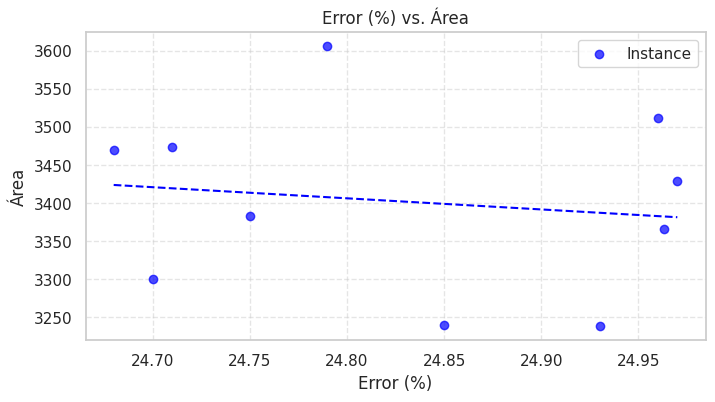

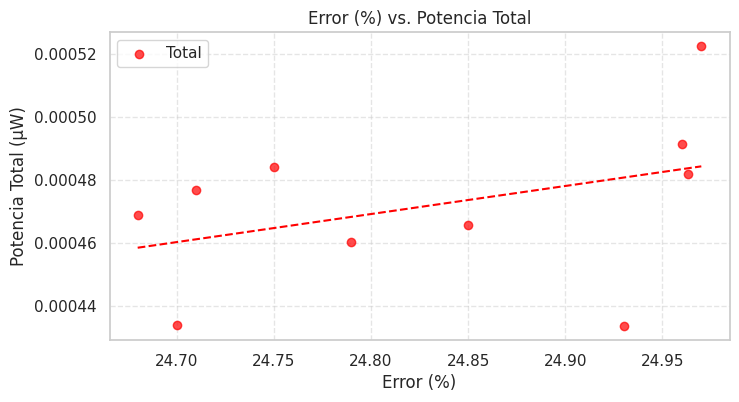

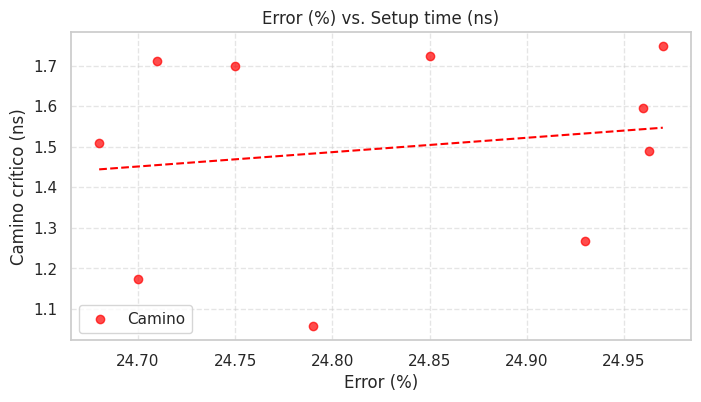

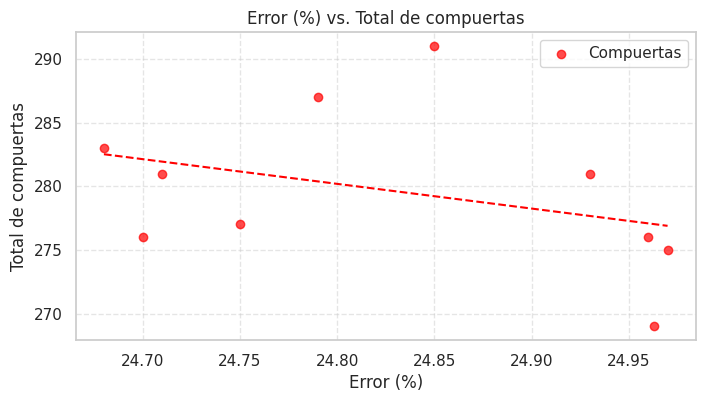

In [16]:
if __name__ == "__main__":
    # Define las carpetas donde buscar CSVs
    carpetas = [
        "/content/drive/MyDrive/Reinforcement Learning Multiplicadores/Fuerza bruta/Análisis de datos/Datos OpenLane/8 bits 2 op"
    ]

    analyzer = OpenLaneAnalyzer(carpetas)
    plotter = Plotter(analyzer)
    for _, row in analyzer.df[["design_name", "error"]].iterrows():
      name = row["design_name"]
      err = row["error"]
      if pd.isna(err):
          err_str = "N/A"
      else:
          # Mostrar entero si es entero, sino con 2 decimales
          if float(err).is_integer():
              err_str = f"{int(err)}"
          else:
              err_str = f"{err:.2f}"
      print(f"{name:<80} -> {err_str}")

    # Dispersión de Celdas por mm2 vs Error (Cell/mm^2)/Core_Util
    plotter.plot_scatter(
        traces=[{"tipo": "Area", "x": "error", "y": "design__instance__area", "color": "blue", "label": "Instance" },
                #{"tipo": "Area", "x": "error", "y": "design__die__area", "color": "red", "label": "DIE"},
                #{"tipo": "Area", "x": "error", "y": "design__core__area", "color": "green", "label": "Core"},
                #{"tipo": "Area", "x": "error", "y": "design__instance__area__stdcell", "color": "yellow", "label":"Std Cell"}
                ],
        title="Error (%) vs. Área",
        xlabel="Error (%)",
        ylabel="Área",
        bits=8,
        tendency=True
    )

    # Comparación de potencia interna en los 3 casos
    plotter.plot_scatter(
        traces=[
            #{"tipo": "Potencia",   "x": "error", "y": "power__switching__total", "color": "blue",  "label": "Switching"},
            {"tipo": "Potencia",  "x": "error", "y": "power__total",  "color": "red", "label": "Total"},
            #{"tipo": "Potencia",  "x": "error", "y": "power__internal__total", "color": "green",   "label": "Interna"},
        ],
        title="Error (%) vs. Potencia Total",
        xlabel="Error (%)",
        ylabel="Potencia Total (µW)",
        bits=8,
        tendency=True
    )

    # Línea de timing vs error
    plotter.plot_scatter(
        traces=[#{"tipo": "Camino", "x": "error", "y": "critical_path_ns", "color": "red"},
                {"tipo": "Camino", "x": "error", "y": "timing__setup__ws__corner:max_tt_025C_1v80", "color": "red"}],
        title="Error (%) vs. Setup time (ns)",
        xlabel="Error (%)",
        ylabel="Camino crítico (ns)",
        bits=8,
        tendency = True
    )

    plotter.plot_scatter(
        traces=[#{"tipo": "Camino", "x": "error", "y": "critical_path_ns", "color": "red"},
                {"tipo": "Compuertas", "x": "error", "y": "design__instance__count__class:multi_input_combinational_cell", "color": "red"}],
        title="Error (%) vs. Total de compuertas",
        xlabel="Error (%)",
        ylabel="Total de compuertas",
        bits=8,
        tendency = True
    )

In [17]:
#plotter.grp['Area']
#plotter.raw['Area']
plotter.raw["Area"].query("bits == 8")

Metric,bits,error,design__die__area,design__core__area,design__instance__area
27,8.0,24.680,40000,33344.5,3469.58
28,8.0,24.700,40000,33344.5,3300.67
29,8.0,24.710,40000,33344.5,3473.33
30,8.0,24.750,40000,33344.5,3383.24
31,8.0,24.790,40000,33344.5,3605.96
32,8.0,24.850,40000,33344.5,3239.36
33,8.0,24.930,40000,33344.5,3238.11
34,8.0,24.963,40000,33344.5,3365.73
35,8.0,24.960,40000,33344.5,3512.12
36,8.0,24.970,40000,33344.5,3429.54


In [18]:
#plotter.grp['Potencia Típica']
#plotter.raw['Potencia']*1000*1000
plotter.raw['Potencia'].query("bits == 8")*1000*1000

Metric,bits,error,power__internal__total,power__switching__total,power__leakage__total,power__total
27,8000000.0,24680000.0,196.365640,272.545585,0.005570,468.916784
28,8000000.0,24700000.0,179.302777,254.528626,0.005421,433.836831
29,8000000.0,24710000.0,199.695714,276.980689,0.005541,476.681918
30,8000000.0,24750000.0,189.822036,294.193684,0.005587,484.021322
31,8000000.0,24790000.0,192.475229,267.646654,0.005456,460.127339
32,8000000.0,24850000.0,186.810808,278.809224,0.005050,465.625082
33,8000000.0,24930000.0,171.487060,261.955312,0.005357,433.447713
34,8000000.0,24963000.0,196.717432,284.985988,0.005229,481.708674
35,8000000.0,24960000.0,208.339217,283.081521,0.005750,491.426501
36,8000000.0,24970000.0,214.466956,308.007322,0.005619,522.479939


In [19]:
#plotter.grp['Camino']
plotter.raw['Camino'].query("bits == 8")

Metric,bits,error,timing__setup__ws__corner:max_tt_025C_1v80
27,8.0,24.680,1.508072
28,8.0,24.700,1.173108
29,8.0,24.710,1.711352
30,8.0,24.750,1.698793
31,8.0,24.790,1.057532
32,8.0,24.850,1.724772
33,8.0,24.930,1.268663
34,8.0,24.963,1.488548
35,8.0,24.960,1.596122
36,8.0,24.970,1.747756


In [20]:
plotter.raw['Compuertas'].query("bits == 8")

Metric,error,bits,design__instance__count__class:multi_input_combinational_cell
27,24.680,8.0,283
28,24.700,8.0,276
29,24.710,8.0,281
30,24.750,8.0,277
31,24.790,8.0,287
32,24.850,8.0,291
33,24.930,8.0,281
34,24.963,8.0,269
35,24.960,8.0,276
36,24.970,8.0,275
